## **Import libraries, data and Preprocessing**

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model

In [2]:
data = pd.read_csv('/content/drive/MyDrive/combined_data.csv')

In [3]:
data.head()

,PDB,chain_id,resSeq,pos,aa,ss,CAx,CAy,CAz,Nx,...,hbE,hbH,cis,phi,psi,omega,lambda,sin_lambda,cos_lambda,lambda_valid
0,1amt,A,1,0,X,C,46.920,3.266,-2.573,48.065,...,0.0,2.0,0,NaN,2.340097,0.077324,NaN,NaN,NaN,0
1,1amt,A,2,1,P,H,44.970,0.437,-4.396,46.136,...,0.0,1.0,0,2.076612,2.566800,0.061647,0.830539,0.738295,0.674478,1
2,1amt,A,3,2,X,H,43.781,-1.151,-1.108,44.584,...,0.0,1.0,0,1.995495,2.266631,0.020281,0.911196,0.790237,0.612801,1
3,1amt,A,4,3,A,H,42.065,2.185,-0.170,43.076,...,0.0,2.0,0,2.153327,2.282802,0.024743,0.995800,0.839194,0.543832,1
4,1amt,A,5,4,X,H,40.420,2.596,-3.610,41.335,...,0.0,2.0,0,2.052216,2.370488,0.032921,1.136675,0.907240,0.420613,1


In [4]:
data.shape

(1469317, 38)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469317 entries, 0 to 1469316
Data columns (total 38 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   PDB           1469317 non-null  object 
 1   chain_id      1469317 non-null  object 
 2   resSeq        1469317 non-null  int64  
 3   pos           1469317 non-null  int64  
 4   aa            1469317 non-null  object 
 5   ss            1469317 non-null  object 
 6   CAx           1469317 non-null  float64
 7   CAy           1469317 non-null  float64
 8   CAz           1469317 non-null  float64
 9   Nx            1469317 non-null  float64
 10  Ny            1469317 non-null  float64
 11  Nz            1469317 non-null  float64
 12  Cx            1469317 non-null  float64
 13  Cy            1469317 non-null  float64
 14  Cz            1469317 non-null  float64
 15  Ox            1469317 non-null  float64
 16  Oy            1469317 non-null  float64
 17  Oz            1469317 non-n

In [6]:
data.isnull().sum()

,0
PDB,0
chain_id,0
resSeq,0
pos,0
aa,0
ss,0
CAx,0
CAy,0
CAz,0
Nx,0


In [7]:
data.describe()

,resSeq,pos,CAx,CAy,CAz,Nx,Ny,Nz,Cx,Cy,...,hbE,hbH,cis,phi,psi,omega,lambda,sin_lambda,cos_lambda,lambda_valid
count,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,1.469317e+06,...,1.469317e+06,1.469317e+06,1.469317e+06,1.462791e+06,1.462791e+06,1.462791e+06,1.456265e+06,1.456265e+06,1.456265e+06,1.469317e+06
mean,2.173436e+02,1.516659e+02,1.435691e+01,1.639416e+01,1.909262e+01,1.435639e+01,1.639353e+01,1.909313e+01,1.435741e+01,1.639466e+01,...,4.919837e-01,9.718522e-01,3.054480e-03,1.403237e+00,6.366498e-01,-1.328296e-02,-4.704359e-01,-3.708825e-02,1.940177e-01,9.911170e-01
std,2.350211e+02,1.284606e+02,3.290956e+01,3.347418e+01,3.672096e+01,3.289029e+01,3.345574e+01,3.670350e+01,3.290100e+01,3.346514e+01,...,7.876328e-01,8.355606e-01,5.518290e-02,9.674205e-01,1.892956e+00,2.075279e-01,1.450251e+00,7.624975e-01,6.161004e-01,9.383036e-02
min,-2.600000e+01,0.000000e+00,-6.440840e+02,-3.424560e+02,-2.905270e+02,-6.428870e+02,-3.422690e+02,-2.904290e+02,-6.437890e+02,-3.415240e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.140929e+00,-3.141592e+00,-3.141581e+00,-3.141547e+00,-1.000000e+00,-1.000000e+00,0.000000e+00
25%,7.800000e+01,5.600000e+01,-2.823000e+00,-2.988000e+00,-9.030000e-01,-2.803000e+00,-2.978000e+00,-8.960000e-01,-2.820000e+00,-2.976000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.097184e+00,-8.254282e-01,-6.588644e-02,-1.944046e+00,-8.590904e-01,-3.967725e-01,1.000000e+00
50%,1.570000e+02,1.200000e+02,1.283600e+01,1.295300e+01,1.462700e+01,1.282900e+01,1.294100e+01,1.462300e+01,1.283700e+01,1.295500e+01,...,0.000000e+00,1.000000e+00,0.000000e+00,1.757371e+00,-1.171372e-01,-1.115822e-02,9.542998e-02,7.986035e-02,5.197937e-01,1.000000e+00
75%,2.760000e+02,2.140000e+02,2.944700e+01,3.167200e+01,3.271100e+01,2.942400e+01,3.164900e+01,3.267600e+01,2.944700e+01,3.166900e+01,...,1.000000e+00,2.000000e+00,0.000000e+00,2.027746e+00,2.451379e+00,4.012272e-02,8.976969e-01,7.744298e-01,6.770621e-01,1.000000e+00
max,3.671000e+03,1.287000e+03,3.361940e+02,4.142510e+02,5.024780e+02,3.370780e+02,4.139000e+02,5.019180e+02,3.355160e+02,4.144690e+02,...,4.000000e+00,4.000000e+00,1.000000e+00,3.139893e+00,3.141592e+00,3.141572e+00,3.141579e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [8]:
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
print("Numeric columns (float + int):")
print(numeric_cols)
numeric_data = data[numeric_cols]
numeric_data = numeric_data.fillna(numeric_data.mean())

Numeric columns (float + int):
Index(['resSeq', 'pos', 'CAx', 'CAy', 'CAz', 'Nx', 'Ny', 'Nz', 'Cx', 'Cy',
       'Cz', 'Ox', 'Oy', 'Oz', 'r13b', 'r13f', 'r14b', 'r14f', 'r15b', 'r15f',
       'n4', 'n45', 'n5', 'n6', 'hbE', 'hbH', 'cis', 'phi', 'psi', 'omega',
       'lambda', 'sin_lambda', 'cos_lambda', 'lambda_valid'],
      dtype='object')


In [9]:
data = data.fillna(data.mode().iloc[0])
data.isnull().sum()

,0
PDB,0
chain_id,0
resSeq,0
pos,0
aa,0
ss,0
CAx,0
CAy,0
CAz,0
Nx,0


In [10]:
# ----- Encode ss -----
ohe_ss = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ss_arr = ohe_ss.fit_transform(data[["ss"]].astype(str))
ss_cols = ohe_ss.get_feature_names_out(["ss"])
df_ss = pd.DataFrame(ss_arr, columns=ss_cols, index=data.index)

# ----- Encode aa -----
ohe_aa = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
aa_arr = ohe_aa.fit_transform(data[["aa"]].astype(str))
aa_cols = ohe_aa.get_feature_names_out(["aa"])
df_aa = pd.DataFrame(aa_arr, columns=aa_cols, index=data.index)

# ----- Build final dataframe -----
df = pd.concat([data.drop(columns=["ss", "aa"]), df_ss, df_aa], axis=1)

In [11]:
# -----------------------------
# 1. One-hot encode chain_id
# -----------------------------
ohe_chain = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
chain_arr = ohe_chain.fit_transform(df[["chain_id"]].astype(str))
chain_cols = ohe_chain.get_feature_names_out(["chain_id"])
df_chain = pd.DataFrame(chain_arr, columns=chain_cols, index=df.index)

# -----------------------------
# 2. Label-encode PDB column
# -----------------------------
le_pdb = LabelEncoder()
pdb_numeric = le_pdb.fit_transform(df["PDB"].astype(str))
df_pdb = pd.DataFrame({"PDB_numeric": pdb_numeric}, index=df.index)

# -----------------------------
# 3. Build final dataframe
# -----------------------------
df = pd.concat(
    [
        df.drop(columns=["chain_id", "PDB"]),
        df_chain,
        df_pdb
    ],
    axis=1
)

In [12]:
df.head()

,resSeq,pos,CAx,CAy,CAz,Nx,Ny,Nz,Cx,Cy,...,chain_id_O,chain_id_P,chain_id_R,chain_id_S,chain_id_U,chain_id_V,chain_id_X,chain_id_Y,chain_id_Z,PDB_numeric
0,1,0,46.920,3.266,-2.573,48.065,2.462,-1.964,45.865,2.301,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11
1,2,1,44.970,0.437,-4.396,46.136,1.294,-3.808,44.079,-0.162,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11
2,3,2,43.781,-1.151,-1.108,44.584,-0.501,-2.166,42.813,-0.016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11
3,4,3,42.065,2.185,-0.170,43.076,1.102,-0.526,41.011,2.324,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11
4,5,4,40.420,2.596,-3.610,41.335,2.427,-2.458,39.578,1.349,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11


In [13]:
target_columns = ["CAx", "CAy", "CAz", "Nx", "Ny", "Nz", "Cx", "Cy", "Cz", "Ox", "Oy", "Oz"]
y = df[target_columns]
X = df

In [14]:
def Preprocessing(X, Y, validation_size = 0.07 ,test_szie = 0.3, seed = 0, shuffle=False):
  X = X.astype(float)
  scaler = MinMaxScaler(feature_range=(-1, 1))
  X_Normalized = scaler.fit_transform(X)
  x_train, x_test, y_train, y_test = train_test_split(
      X_Normalized, Y, test_size = test_szie, shuffle = shuffle, random_state = seed
  )
  x_train, x_val, y_train, y_val = train_test_split(
      x_train, y_train, test_size = validation_size, shuffle = shuffle, random_state=seed
  )
  print("x_train shape:", x_train.shape)
  print("y_train shape:", y_train.shape)
  print("x_val shape:", x_val.shape)
  print("y_val shape:", y_val.shape)
  print("x_test shape:", x_test.shape)
  print("y_test shape:", y_test.shape)
  return x_train, x_val, x_test , y_train, y_val, y_test

In [15]:
x_train, x_val, x_test , y_train, y_val, y_test = Preprocessing(X, y, validation_size = 0.07 ,test_szie = 0.30, seed = 0, shuffle=False)

x_train shape: (956524, 82)
y_train shape: (956524, 12)
x_val shape: (71997, 82)
y_val shape: (71997, 12)
x_test shape: (440796, 82)
y_test shape: (440796, 12)


## **Model (Autoencoder)**

In [ ]:
input_dim = X.shape[1]
output_dim = y.shape[1]   # should be 12
latent_dim = 64

# -----------------------------
# Custom metrics
# -----------------------------
def mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

def rmsd(y_true, y_pred):
    # RMSD = sqrt(mean(||p - q||^2))
    diff = y_true - y_pred
    diff = tf.reshape(diff, (-1, 4, 3))  # 4 atoms × 3 coords
    dist_sq = tf.reduce_sum(tf.square(diff), axis=-1)
    return tf.sqrt(tf.reduce_mean(dist_sq))

def crmsd(y_true, y_pred):
    # Center both sets before RMSD
    y_true_centered = y_true - tf.reduce_mean(y_true, axis=1, keepdims=True)
    y_pred_centered = y_pred - tf.reduce_mean(y_pred, axis=1, keepdims=True)
    diff = y_true_centered - y_pred_centered
    diff = tf.reshape(diff, (-1, 4, 3))
    dist_sq = tf.reduce_sum(tf.square(diff), axis=-1)
    return tf.sqrt(tf.reduce_mean(dist_sq))

# -----------------------------
# Encoder
# -----------------------------
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(512, activation='relu')(inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='linear')(x)

# -----------------------------
# Decoder
# -----------------------------
d = layers.Dense(128, activation='relu')(latent)
d = layers.Dense(64, activation='relu')(d)
d = layers.Dense(32, activation='relu')(d)
outputs = layers.Dense(output_dim, activation='linear')(d)

# -----------------------------
# Model
# -----------------------------
model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=mae,
    metrics=[mae, rmse, rmsd, crmsd]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 82)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        42,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,028 (914.17 KB)

 Trainable params: 234,028 (914.17 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=256,
    verbose=1
)

Epoch 1/100
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - crmsd: 20.9544 - loss: 9.2655 - mae: 9.2655 - rmsd: 24.2895 - rmse: 14.0235 - val_crmsd: 2.6310 - val_loss: 1.2703 - val_mae: 1.2699 - val_rmsd: 2.7621 - val_rmse: 1.5947
Epoch 2/100
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - crmsd: 2.3823 - loss: 1.1926 - mae: 1.1926 - rmsd: 2.6850 - rmse: 1.5502 - val_crmsd: 1.8846 - val_loss: 0.9251 - val_mae: 0.9249 - val_rmsd: 1.9999 - val_rmse: 1.1546
Epoch 3/100
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - crmsd: 1.9349 - loss: 0.9690 - mae: 0.9690 - rmsd: 2.1223 - rmse: 1.2253 - val_crmsd: 1.7868 - val_loss: 0.9180 - val_mae: 0.9177 - val_rmsd: 1.9891 - val_rmse: 1.1484
Epoch 4/100
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - crmsd: 1.7987 - loss: 0.9041 - mae: 0.9041 - rmsd: 1.9691 - rmse: 1.1369 - val_crmsd: 1.6006 - val_loss: 0.7816 - val_mae: 0.7815 - val_rmsd: 1.6936 - val_rmse: 0.9778
Epoch 5/100
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - crmsd: 1.7567 - loss: 0.8836 - mae:

In [ ]:
model.evaluate(x_test, y_test)

13775/13775 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - crmsd: 1.5315 - loss: 0.7461 - mae: 0.7461 - rmsd: 1.6072 - rmse: 0.9279


[0.8830263614654541,
 0.883024275302887,
 1.1144523620605469,
 1.930286169052124,
 1.7477973699569702]

## **Model (CNN Attention)**

In [ ]:
import tensorflow as tf

def mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

def rmsd(y_true, y_pred):
    diff = y_true - y_pred
    diff = tf.reshape(diff, (-1, 4, 3))  # 4 atoms × 3 coords
    dist_sq = tf.reduce_sum(tf.square(diff), axis=-1)
    return tf.sqrt(tf.reduce_mean(dist_sq))

def crmsd(y_true, y_pred):
    y_true_c = y_true - tf.reduce_mean(y_true, axis=1, keepdims=True)
    y_pred_c = y_pred - tf.reduce_mean(y_pred, axis=1, keepdims=True)
    diff = y_true_c - y_pred_c
    diff = tf.reshape(diff, (-1, 4, 3))
    dist_sq = tf.reduce_sum(tf.square(diff), axis=-1)
    return tf.sqrt(tf.reduce_mean(dist_sq))

In [ ]:
from tensorflow.keras import layers

def attention_block(x):
    # Channel attention
    avg_pool = layers.GlobalAveragePooling1D()(x)
    dense1 = layers.Dense(x.shape[-1] // 2, activation="relu")(avg_pool)
    dense2 = layers.Dense(x.shape[-1], activation="sigmoid")(dense1)
    scale = layers.Multiply()([x, layers.Reshape((1, x.shape[-1]))(dense2)])
    return scale

In [ ]:
def build_cnn_attention(input_dim, output_dim=12):
    inputs = layers.Input(shape=(input_dim,))

    # reshape to (batch, features, 1)
    x = layers.Reshape((input_dim, 1))(inputs)

    # CNN feature extractor
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    # Attention
    x = attention_block(x)

    # Decoder
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(output_dim, activation="linear")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=mae,
        metrics=[mae, rmse, rmsd, crmsd]
    )

    return model

In [ ]:
input_dim = x_train.shape[1]

model = build_cnn_attention(input_dim)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)

Epoch 1/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 60s 7ms/step - crmsd: 15.7392 - loss: 6.2044 - mae: 6.2044 - rmsd: 17.8883 - rmse: 10.3278 - val_crmsd: 2.0906 - val_loss: 1.1664 - val_mae: 1.1663 - val_rmsd: 2.5315 - val_rmse: 1.4615
Epoch 2/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - crmsd: 1.8660 - loss: 0.8544 - mae: 0.8544 - rmsd: 2.0080 - rmse: 1.1593 - val_crmsd: 1.8531 - val_loss: 0.8977 - val_mae: 0.8975 - val_rmsd: 1.9350 - val_rmse: 1.1172
Epoch 3/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - crmsd: 1.6194 - loss: 0.7511 - mae: 0.7511 - rmsd: 1.7259 - rmse: 0.9964 - val_crmsd: 1.4904 - val_loss: 0.8476 - val_mae: 0.8474 - val_rmsd: 1.8227 - val_rmse: 1.0523
Epoch 4/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - crmsd: 1.3079 - loss: 0.6037 - mae: 0.6037 - rmsd: 1.4211 - rmse: 0.8205 - val_crmsd: 1.2006 - val_loss: 0.5873 - val_mae: 0.5872 - val_rmsd: 1.3123 - val_rmse: 0.7577
Epoch 5/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - crmsd: 1.0446 - loss: 0.4882 - mae: 0.48

In [ ]:
model.evaluate(x_test, y_test)

## **Model (GRU)**

In [ ]:
import tensorflow as tf

def mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

def rmsd(y_true, y_pred):
    diff = y_true - y_pred
    diff = tf.reshape(diff, (-1, 4, 3))
    dist_sq = tf.reduce_sum(tf.square(diff), axis=-1)
    return tf.sqrt(tf.reduce_mean(dist_sq))

def crmsd(y_true, y_pred):
    y_true_c = y_true - tf.reduce_mean(y_true, axis=1, keepdims=True)
    y_pred_c = y_pred - tf.reduce_mean(y_pred, axis=1, keepdims=True)
    diff = y_true_c - y_pred_c
    diff = tf.reshape(diff, (-1, 4, 3))
    dist_sq = tf.reduce_sum(tf.square(diff), axis=-1)
    return tf.sqrt(tf.reduce_mean(dist_sq))

In [ ]:
# reshape (batch, features) → (batch, features, 1)
x_train_r = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_val_r   = x_val.reshape(x_val.shape[0], x_val.shape[1], 1)
x_test_r  = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

In [ ]:
from tensorflow.keras import layers, Model

def build_gru_model(input_dim, output_dim=12):
    inputs = layers.Input(shape=(input_dim, 1))

    x = layers.GRU(256, return_sequences=True)(inputs)
    x = layers.GRU(128)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)

    outputs = layers.Dense(output_dim, activation="linear")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=mae,
        metrics=[mae, rmse, rmsd, crmsd]
    )

    return model

In [ ]:
input_dim = x_train.shape[1]
model = build_gru_model(input_dim)

history = model.fit(
    x_train_r, y_train,
    validation_data=(x_val_r, y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)

Epoch 1/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 148s 19ms/step - crmsd: 33.5989 - loss: 16.2152 - mae: 16.2152 - rmsd: 39.4008 - rmse: 22.7481 - val_crmsd: 2.2165 - val_loss: 1.5038 - val_mae: 1.5033 - val_rmsd: 3.2185 - val_rmse: 1.8582
Epoch 2/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 144s 19ms/step - crmsd: 2.5941 - loss: 1.0329 - mae: 1.0329 - rmsd: 2.9889 - rmse: 1.7256 - val_crmsd: 1.6956 - val_loss: 0.8218 - val_mae: 0.8217 - val_rmsd: 1.8060 - val_rmse: 1.0427
Epoch 3/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 145s 19ms/step - crmsd: 1.6409 - loss: 0.7753 - mae: 0.7753 - rmsd: 1.7829 - rmse: 1.0294 - val_crmsd: 1.5504 - val_loss: 0.7846 - val_mae: 0.7845 - val_rmsd: 1.7081 - val_rmse: 0.9862
Epoch 4/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 145s 19ms/step - crmsd: 1.5279 - loss: 0.7312 - mae: 0.7312 - rmsd: 1.6304 - rmse: 0.9413 - val_crmsd: 1.4647 - val_loss: 0.7831 - val_mae: 0.7831 - val_rmsd: 1.6984 - val_rmse: 0.9806
Epoch 5/50
7473/7473 ━━━━━━━━━━━━━━━━━━━━ 145s 19ms/step - crmsd: 1.4940 - loss: 0.7135

KeyboardInterrupt: 

In [ ]:
model.evaluate(x_test_r, y_test)

## **Model (CNN Attention)**

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import keras

# -------------------------
# Custom Metrics
# -------------------------
def mae_div3(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def rmse_div3(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

def rmsd_div3(y_true, y_pred):
    diff = y_true - y_pred
    diff = tf.reshape(diff, (-1, 4, 3))
    dist_sq = tf.reduce_sum(tf.square(diff), axis=-1)
    return tf.sqrt(tf.reduce_mean(dist_sq))

def crmsd_div3(y_true, y_pred):
    y_true_c = y_true - tf.reduce_mean(y_true, axis=1, keepdims=True)
    y_pred_c = y_pred - tf.reduce_mean(y_pred, axis=1, keepdims=True)
    diff = y_true_c - y_pred_c
    diff = tf.reshape(diff, (-1, 4, 3))
    dist_sq = tf.reduce_sum(tf.square(diff), axis=-1)
    return tf.sqrt(tf.reduce_mean(dist_sq))

# -------------------------
# CBAM Attention (Channel + Spatial)
# -------------------------
def cbam_block(x, reduction=8):
    channels = x.shape[-1]

    # ----- Channel Attention -----
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)

    mlp = layers.Dense(channels // reduction, activation="swish")
    mlp_out = layers.Dense(channels)

    avg_out = mlp_out(mlp(avg_pool))
    max_out = mlp_out(mlp(max_pool))

    channel_attention = layers.Activation("sigmoid")(avg_out + max_out)
    channel_attention = layers.Reshape((1, channels))(channel_attention)
    x = layers.Multiply()([x, channel_attention])

    # ----- Spatial Attention -----
    avg_pool = keras.ops.mean(x, axis=-1, keepdims=True)
    max_pool = keras.ops.max(x, axis=-1, keepdims=True)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = layers.Conv1D(1, kernel_size=7, padding="same",
                                      activation="sigmoid")(concat)
    x = layers.Multiply()([x, spatial_attention])

    return x

# -------------------------
# Residual CNN Block
# -------------------------
def residual_cnn_block(x, filters):
    shortcut = x

    x = layers.Conv1D(filters, 5, padding="same", activation="swish")(x)
    x = layers.Conv1D(filters, 5, padding="same", activation="swish")(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    return layers.Add()([x, shortcut])

# -------------------------
# Reduced Model
# -------------------------
def build_residual_cnn_cbam_small(input_dim, output_dim=12):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim, 1))(inputs)

    # CNN Block 1
    x = residual_cnn_block(x, 64)
    x = cbam_block(x)
    x = layers.MaxPooling1D(2)(x)

    # CNN Block 2 (reduced depth)
    x = residual_cnn_block(x, 128)
    x = cbam_block(x)

    # Decoder (reduced)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="swish")(x)
    x = layers.Dense(128, activation="swish")(x)

    outputs = layers.Dense(output_dim, activation="linear")(x)

    model = Model(inputs, outputs)

    model.compile(
      optimizer=tf.keras.optimizers.Adam(1e-3),
      loss=mae_div3,
      metrics=[mae_div3, rmse_div3, rmsd_div3, crmsd_div3]
    )


    return model

In [19]:
# -------------------------
# Build + Train
# -------------------------
input_dim = x_train.shape[1]
model = build_residual_cnn_cbam_small(input_dim)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=256,
    verbose=1
)

Epoch 1/200
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 55s 13ms/step - crmsd_div3: 5.6923 - loss: 2.5363 - mae_div3: 2.5363 - rmsd_div3: 6.5229 - rmse_div3: 3.7660 - val_crmsd_div3: 0.9012 - val_loss: 0.4162 - val_mae_div3: 0.4160 - val_rmsd_div3: 0.9261 - val_rmse_div3: 0.5347
Epoch 2/200
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - crmsd_div3: 0.7833 - loss: 0.2983 - mae_div3: 0.2983 - rmsd_div3: 0.8276 - rmse_div3: 0.4778 - val_crmsd_div3: 0.7242 - val_loss: 0.3331 - val_mae_div3: 0.3330 - val_rmsd_div3: 0.7427 - val_rmse_div3: 0.4288
Epoch 3/200
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - crmsd_div3: 0.5800 - loss: 0.2679 - mae_div3: 0.2679 - rmsd_div3: 0.6160 - rmse_div3: 0.3556 - val_crmsd_div3: 0.5928 - val_loss: 0.2846 - val_mae_div3: 0.2845 - val_rmsd_div3: 0.6314 - val_rmse_div3: 0.3645
Epoch 4/200
3737/3737 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - crmsd_div3: 0.5300 - loss: 0.2493 - mae_div3: 0.2493 - rmsd_div3: 0.5635 - rmse_div3: 0.3253 - val_crmsd_div3: 0.5750 - val_loss: 0.2672 - v

13775/13775 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step


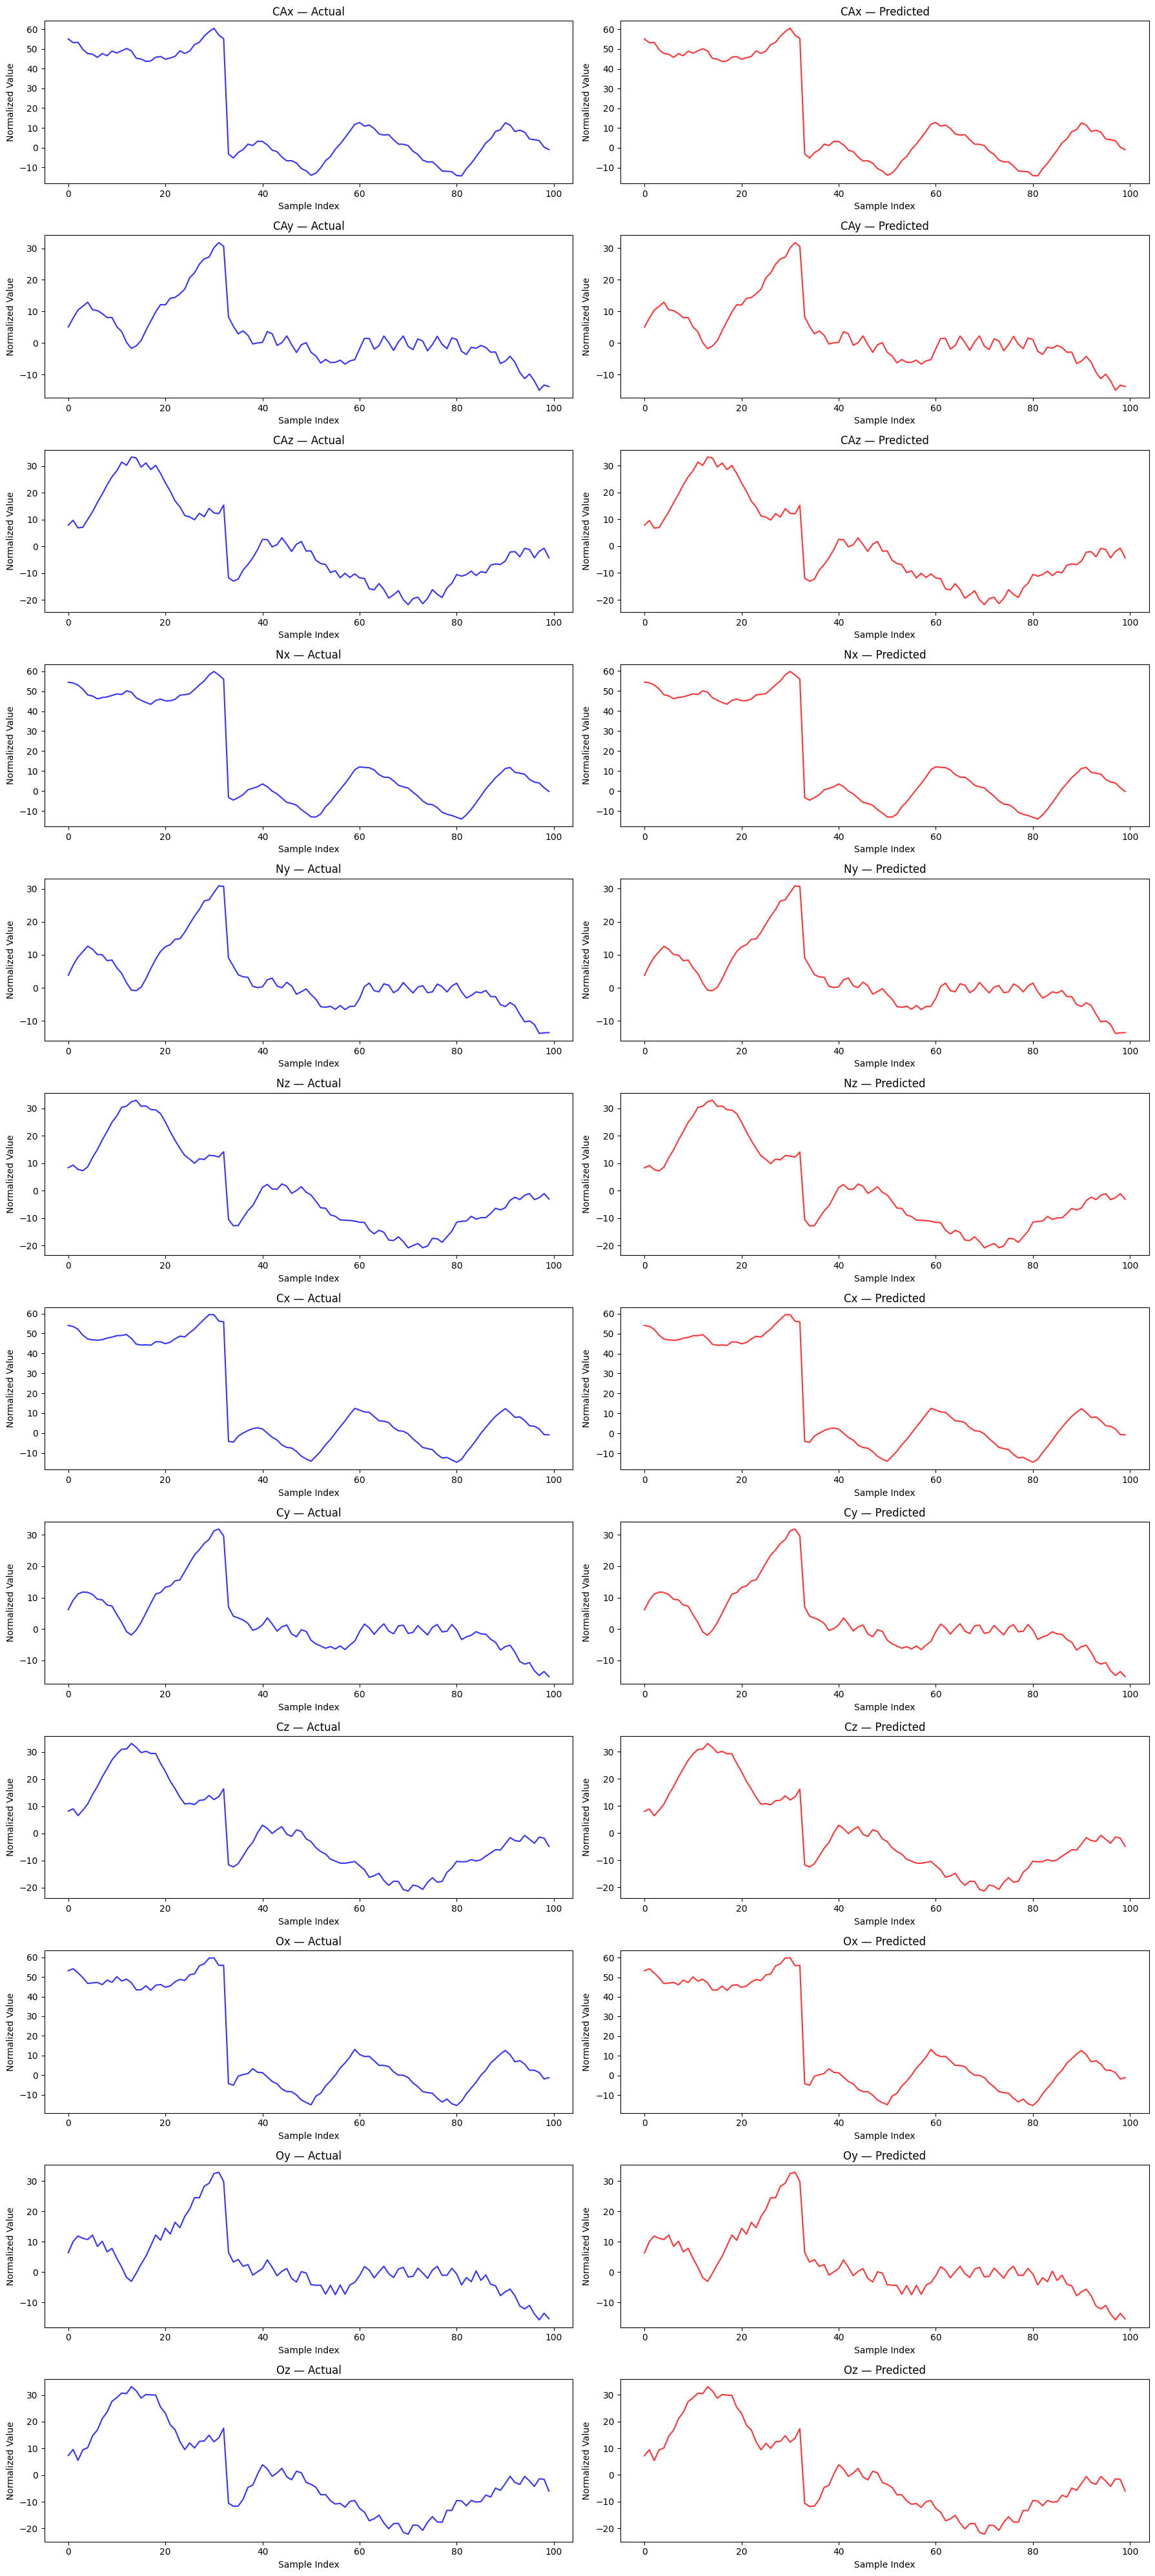

In [27]:
import matplotlib.pyplot as plt

# 1. Predict
y_pred = model.predict(x_test)

# 2. Use normalized values directly (no scaler available)
y_pred_real = y_pred
y_test_real = y_test.values  # Convert DataFrame to NumPy array

# 3. Limit to first 100 samples
y_pred_100 = y_pred_real[:100]
y_test_100 = y_test_real[:100]

# 4. Your target names
target_columns = ["CAx", "CAy", "CAz",
                  "Nx", "Ny", "Nz",
                  "Cx", "Cy", "Cz",
                  "Ox", "Oy", "Oz"]

# 5. Plot each of the 12 targets
plt.figure(figsize=(18, 40))  # Taller figure because we now have 24 plots

for i in range(12):
    # Actual
    plt.subplot(12, 2, 2*i + 1)
    plt.plot(y_test_100[:, i], color="blue", alpha=0.8)
    plt.title(f"{target_columns[i]} — Actual")
    plt.xlabel("Sample Index")
    plt.ylabel("Normalized Value")

    # Predicted
    plt.subplot(12, 2, 2*i + 2)
    plt.plot(y_pred_100[:, i], color="red", alpha=0.8)
    plt.title(f"{target_columns[i]} — Predicted")
    plt.xlabel("Sample Index")
    plt.ylabel("Normalized Value")

plt.tight_layout()
plt.show()
